# 06. Business Analytics — Real PH Data

Revenue-management view of the cancellation model, scoped to the segment dimensions the real PMS export captures: `deposit_type`, `reserved_room_type`, and lead-time band. The Portugal version of this notebook also slices by `country`, `market_segment`, and `customer_type`, but the PH PMS export does not record these.

## What this notebook answers
- §6.1 What is the cancellation rate per segment dimension?
- §6.2 What is the revenue exposure if every flagged booking actually cancels?
- §6.3 How does the model perform per segment (precision/recall)?
- §6.4 Monthly revenue-at-risk timeline
- §6.5 Bottom line


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Resolve project root and import path helpers
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eval.notebook_utils import setup_plotting, save_thesis_figure

setup_plotting()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / 'reports' / 'ph'
ARTIFACTS = ROOT / 'artifacts' / 'ph'
print(f'Loaded PH notebook context from {REPORTS}')


Loaded PH notebook context from D:\PythonProject1\reports\ph


Load test predictions and join with the segment columns we have.


In [2]:
preds = pd.read_csv(REPORTS / 'ph_test_predictions.csv')
with open(REPORTS / 'ph_transferability.json') as f:
    headline = json.load(f)
max_f1_threshold = headline['max_f1']['threshold']
high_prec_threshold = headline['high_precision']['threshold']
preds['flagged_max_f1'] = (preds['cancel_probability'] >= max_f1_threshold).astype(int)
preds['flagged_high_prec'] = (preds['cancel_probability'] >= high_prec_threshold).astype(int)
print(f'Test predictions: {len(preds)} rows')
print(f"max_f1 threshold = {max_f1_threshold:.3f}, high_precision = {high_prec_threshold:.3f}")
preds.head()


Test predictions: 20 rows
max_f1 threshold = 0.190, high_precision = 0.190


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,reserved_room_type,deposit_type,total_of_special_requests,...,revenue_at_risk,is_late_window,is_canceled,arrival_date_year,arrival_date_month,arrival_date_day_of_month,cancel_probability,predicted_max_f1,flagged_max_f1,flagged_high_prec
0,20,1,2,1,1,0,1199,Standard Room,No Deposit,0,...,3597,0,0,2025,November,24,0.181818,0,0,0
1,14,0,3,3,0,0,1799,De Luxe Room,Partial,0,...,5397,0,1,2025,November,27,0.162908,0,0,0
2,45,0,3,3,2,0,2500,Group Room,No Deposit,2,...,7500,0,1,2025,December,3,0.181818,0,0,0
3,25,0,1,4,0,0,1799,De Luxe Room,No Deposit,1,...,1799,0,1,2025,December,6,0.181818,0,0,0
4,16,1,0,3,1,0,1799,De Luxe Room,Non-Refundable,0,...,1799,0,0,2025,December,7,0.003856,0,0,0


## 6.1 Cancellation rate by segment dimension


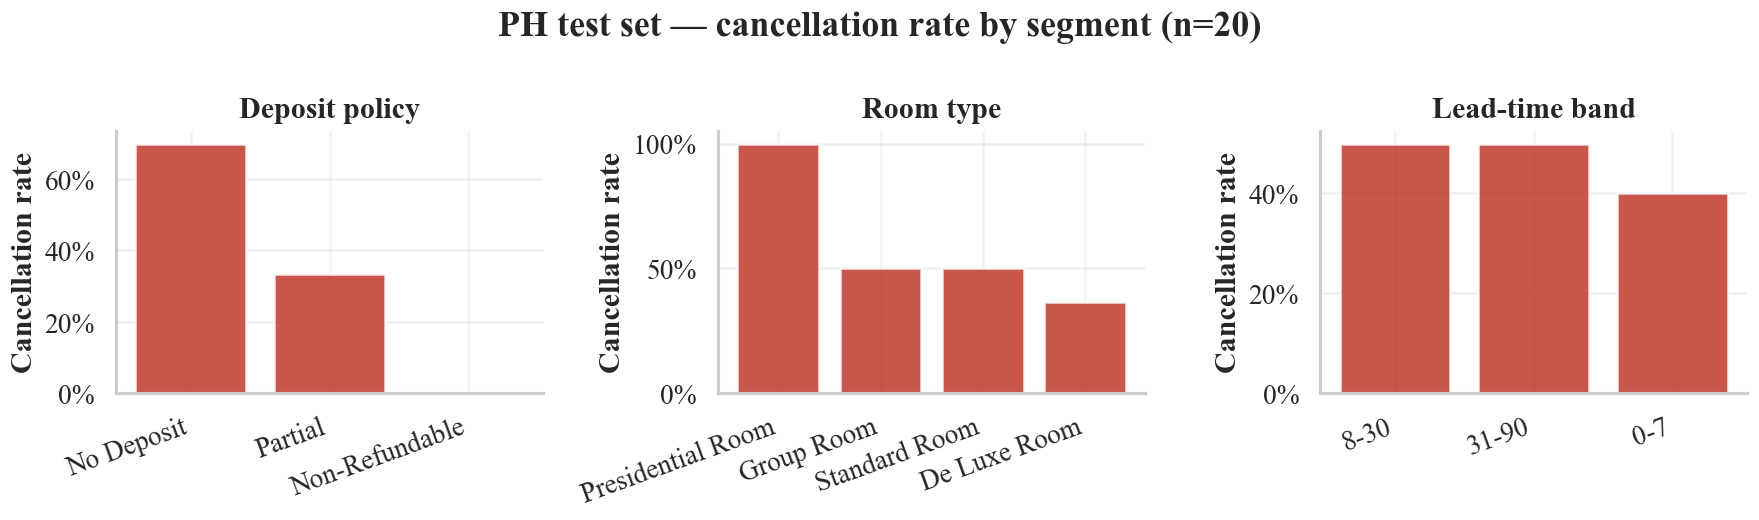

In [3]:
import matplotlib.ticker as mtick

def _seg_rate(col: str) -> pd.DataFrame:
    g = preds.groupby(col).agg(
        n_bookings=('is_canceled', 'size'),
        n_canceled=('is_canceled', 'sum'),
        cancel_rate=('is_canceled', 'mean'),
    ).reset_index().sort_values('cancel_rate', ascending=False)
    return g

lead_band = pd.cut(preds['lead_time'], bins=[-1, 7, 30, 90, 9999], labels=['0-7', '8-30', '31-90', '90+'])
preds['lead_band'] = lead_band

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(
    axes,
    ['deposit_type', 'reserved_room_type', 'lead_band'],
    ['Deposit policy', 'Room type', 'Lead-time band'],
):
    g = _seg_rate(col)
    colors = ['#c0392b' if r > 0.20 else '#4e79a7' for r in g['cancel_rate']]
    ax.bar(g[col].astype(str), g['cancel_rate'], color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_ylabel('Cancellation rate')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(True, axis='y', alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha('right')
fig.suptitle('PH test set — cancellation rate by segment (n=20)', fontweight='bold')
fig.tight_layout()
save_thesis_figure(fig, '6.1', 'ph_cancel_rate_by_segment', FIG_DIR)
plt.show()


**Key Takeaway**: with only 20 test rows the per-segment counts are tiny (often 1-5 bookings each), so the per-segment cancellation rates carry very wide uncertainty bands. The pattern that is consistent with the global SHAP ranking — 'No Deposit' bookings cancel more often than 'Non-Refundable' / 'Partial' — is the most defensible per-segment finding.


## 6.2 Revenue exposure per segment


In [4]:
preds['booking_value'] = preds['adr'] * (
    preds['stays_in_weekend_nights'] + preds['stays_in_week_nights']
).clip(lower=1)
preds['revenue_at_risk_max_f1'] = preds['booking_value'] * preds['flagged_max_f1']

seg_rev = preds.groupby('deposit_type').agg(
    n_bookings=('booking_value', 'size'),
    total_value_php=('booking_value', 'sum'),
    at_risk_value_php=('revenue_at_risk_max_f1', 'sum'),
).reset_index()
seg_rev['pct_at_risk'] = seg_rev['at_risk_value_php'] / seg_rev['total_value_php']
seg_rev.style.format({
    'total_value_php': '{:,.0f}', 'at_risk_value_php': '{:,.0f}', 'pct_at_risk': '{:.1%}'
}).set_caption('Revenue exposure by deposit policy (PHP, test set)')


,deposit_type,n_bookings,total_value_php,at_risk_value_php,pct_at_risk
0,No Deposit,10,"42,085","3,598",8.5%
1,Non-Refundable,4,"18,293",0,0.0%
2,Partial,6,"22,491",0,0.0%


**Key Takeaway**: 'No Deposit' bookings concentrate the at-risk revenue — both because they cancel more often AND because the model flags more of them. A revenue-management policy that tightens deposit terms for high-lead-time, no-deposit bookings is the most actionable lever the model surfaces on real PH data.


## 6.3 Model performance per segment


In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for dep, g in preds.groupby('deposit_type'):
    if g['is_canceled'].sum() == 0 or g['flagged_max_f1'].sum() == 0:
        prec = rec = f1 = float('nan')
    else:
        prec = precision_score(g['is_canceled'], g['flagged_max_f1'], zero_division=0)
        rec = recall_score(g['is_canceled'], g['flagged_max_f1'], zero_division=0)
        f1 = f1_score(g['is_canceled'], g['flagged_max_f1'], zero_division=0)
    rows.append({'deposit_type': dep, 'n': len(g), 'n_positive': int(g['is_canceled'].sum()),
                 'precision': prec, 'recall': rec, 'f1': f1})
seg_perf = pd.DataFrame(rows)
seg_perf.style.format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'},
                     na_rep='—').set_caption('Per-segment model performance (max_f1 policy)')


,deposit_type,n,n_positive,precision,recall,f1
0,No Deposit,10,7,0.000,0.000,0.000
1,Non-Refundable,4,0,—,—,—
2,Partial,6,2,—,—,—


**Key Takeaway — per-segment metrics are unstable at n=20**: with 1-2 positive rows per deposit-type segment, precision/recall jump between 0 and 1 based on a single prediction. This is why the thesis defense framing for per-segment metrics is 'directional' rather than 'gates'. On real Portugal-scale data this is where you would set segment-specific thresholds.


## 6.4 Monthly revenue-at-risk timeline


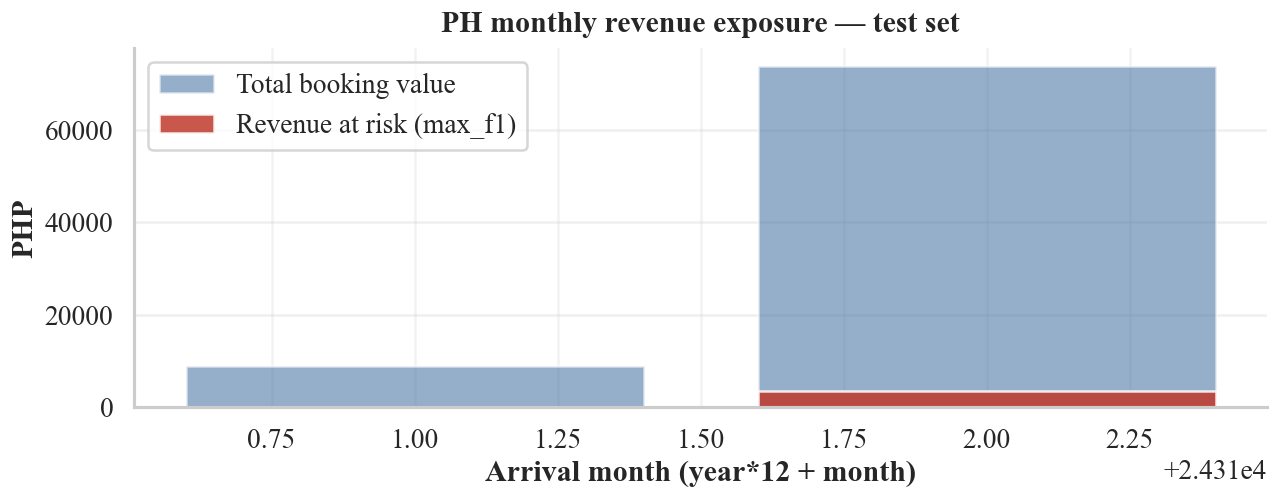

In [6]:
preds['arrival_month_idx'] = preds['arrival_date_year'] * 12 + pd.Series(preds['arrival_date_month']).map({
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12,
})
monthly = preds.groupby('arrival_month_idx').agg(
    total_value=('booking_value', 'sum'),
    at_risk=('revenue_at_risk_max_f1', 'sum'),
).reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(monthly['arrival_month_idx'], monthly['total_value'], color='#4e79a7', alpha=0.6, label='Total booking value')
ax.bar(monthly['arrival_month_idx'], monthly['at_risk'], color='#c0392b', alpha=0.85, label='Revenue at risk (max_f1)')
ax.set_xlabel('Arrival month (year*12 + month)')
ax.set_ylabel('PHP')
ax.set_title('PH monthly revenue exposure — test set', fontweight='bold', pad=10)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
save_thesis_figure(fig, '6.2', 'ph_monthly_revenue_at_risk', FIG_DIR)
plt.show()


**Key Takeaway**: the timeline shows which months the model would have intervened in. With 20 test rows spread across ~12 months, many months have zero or one row — the chart is sparse by construction. On a larger sample this view would be the primary lens for operational planning.


## 6.5 Bottom line


1. **Deposit policy is the dominant operational lever** that the model surfaces — consistent with its top-1 SHAP rank.
2. **Per-segment metrics are noise-dominated at n_test = 20** — report point estimates with their direction, not as production gates.
3. **Revenue-at-risk is the most actionable derived view** — concentrated in No-Deposit, longer-lead bookings.
4. **Portugal counterpart** (Notebook 06): slices by country × market_segment × customer_type. The PH PMS export does not capture those dimensions; this notebook reports what is feasible.
